<a href="https://colab.research.google.com/github/tim9859694-lgtm/data-mining/blob/main/%EB%A7%88%EC%9D%B4%EB%8B%9D%206%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 데이터 불러오기
import pandas as pd
# train = pd.read_csv("train.csv")
# test = pd.read_csv("test.csv")
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/test.csv")

In [5]:
# 데이터 크기 확인
train.shape, test.shape

((3759, 9), (1617, 8))

In [7]:
# 샘플 확인
train.head(3)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,EcoSport,2017,10298,Manual,25013,Petrol,150,53.3,1.0
1,Focus,2016,10491,Manual,30970,Diesel,0,74.3,1.5
2,S-MAX,2017,13498,Manual,60200,Diesel,150,56.5,2.0


In [9]:
test.head(3)

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,S-MAX,2016,Manual,23905,Diesel,125,56.5,2.0
1,Fiesta,2018,Manual,16895,Petrol,145,40.3,1.5
2,Kuga,2017,Manual,12109,Petrol,165,45.6,1.5


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3759 entries, 0 to 3758
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         3759 non-null   object 
 1   year          3759 non-null   int64  
 2   price         3759 non-null   int64  
 3   transmission  3759 non-null   object 
 4   mileage       3759 non-null   int64  
 5   fuelType      3759 non-null   object 
 6   tax           3759 non-null   int64  
 7   mpg           3759 non-null   float64
 8   engineSize    3759 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 264.4+ KB


In [13]:
train.describe()

,year,price,mileage,tax,mpg,engineSize
count,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000
mean,2016.887736,12353.321362,23191.786379,114.444001,57.793083,1.352807
std,2.151811,4750.338051,19223.258713,61.713682,10.099221,0.437130
min,2002.000000,1095.000000,5.000000,0.000000,20.900000,0.000000
25%,2016.000000,9000.000000,9997.500000,75.000000,52.300000,1.000000
50%,2017.000000,11495.000000,18180.000000,145.000000,58.900000,1.200000
75%,2018.000000,15310.000000,31000.000000,145.000000,65.700000,1.500000
max,2060.000000,48000.000000,144000.000000,570.000000,201.800000,5.000000


In [15]:
train.describe()

,year,price,mileage,tax,mpg,engineSize
count,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000,3759.000000
mean,2016.887736,12353.321362,23191.786379,114.444001,57.793083,1.352807
std,2.151811,4750.338051,19223.258713,61.713682,10.099221,0.437130
min,2002.000000,1095.000000,5.000000,0.000000,20.900000,0.000000
25%,2016.000000,9000.000000,9997.500000,75.000000,52.300000,1.000000
50%,2017.000000,11495.000000,18180.000000,145.000000,58.900000,1.200000
75%,2018.000000,15310.000000,31000.000000,145.000000,65.700000,1.500000
max,2060.000000,48000.000000,144000.000000,570.000000,201.800000,5.000000


In [17]:
train.describe(include='O')

,model,transmission,fuelType
count,3759,3759,3759
unique,19,3,3
top,Fiesta,Manual,Petrol
freq,1372,3234,2541


In [19]:
test.isnull().sum().sum()

np.int64(0)

In [21]:
train['price'].value_counts()


,count
price,
12000,33
9000,31
11000,30
11500,27
10000,27
...,...
5700,1
7481,1
8194,1


<Axes: >

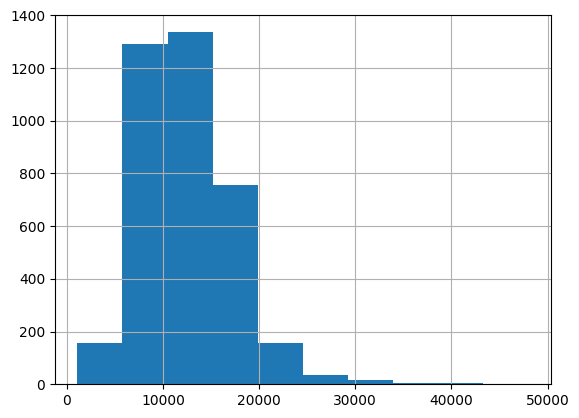

In [23]:
train['price'].hist()

In [43]:
target = train.pop('price')

print(train.shape, test.shape)
train = pd.get_dummies(train)
test = pd.get_dummies(test)
print(train.shape, test.shape)

KeyError: 'price'

In [35]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

((3007, 8), (752, 8), (3007,), (752,))

In [28]:
from sklearn.metrics import root_mean_squared_error

In [34]:
# 선형회귀
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tr, y_tr)
pred = lr.predict(X_val)
root_mean_squared_error(y_val, pred)

2438.5721503083023

In [36]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_val)
root_mean_squared_error(y_val, pred)

1302.5271377093507

In [37]:
# Xgboost
import xgboost as xgb
xg = xgb.XGBRegressor(random_state=0)
xg.fit(X_tr, y_tr)
pred = xg.predict(X_val)
root_mean_squared_error(y_val, pred)

1282.92041015625

In [38]:
# LightGBM
import lightgbm as lgb
lg = lgb.LGBMRegressor(random_state=0, verbose=-1)
lg.fit(X_tr, y_tr)
pred = lg.predict(X_val)
root_mean_squared_error(y_val, pred)

1188.060473375616

In [39]:
pred = lg.predict(test)
result = pd.DataFrame({
    'pred':pred
})
result.to_csv("result.csv", index=False)

In [40]:
# 데이터 불러오기
import pandas as pd
# train = pd.read_csv("train.csv")
# test = pd.read_csv("test.csv")
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/test.csv")

# target 데이터
target = train.pop('price')

# 레이블 인코딩
from sklearn.preprocessing import LabelEncoder
cols = train.select_dtypes(include='O').columns

for col in cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# 검증데이터 분리
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

# LightGBM
import lightgbm as lgb
lg = lgb.LGBMRegressor(random_state=0, verbose=-1)
lg.fit(X_tr, y_tr)
pred = lg.predict(X_val)

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_val, pred)

# 베이스라인(원핫 인코딩): 1221.9041801017495
# 레이블 인코딩: 1184.573934411357

1188.060473375616

In [42]:

# 최종 제출 파일
pred = lg.predict(test)
result = pd.DataFrame({
    'pred':pred
})
result.to_csv("result.csv", index=False)